<a href="https://colab.research.google.com/github/9245dharsans-dotcom/Blur-Image-Detector/blob/main/blur_image_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#installing kagglehub
!pip install kagglehub
import kagglehub
path = kagglehub.dataset_download("kwentar/blur-dataset")
print(path)

100%|██████████| 1.49G/1.49G [00:20<00:00, 79.6MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2


In [6]:
#checking the total path
import os
path = "/root/.cache/kagglehub/datasets/kwentar/blur-dataset/versions/2"
print(os.listdir(path))

['sharp', 'motion_blurred', 'blur_dataset_scaled', 'defocused_blurred']


In [34]:
#getting the total count of sharp , blurry and motion blurry images
sharp_path = path + "/sharp"
blur_path = path + "/defocused_blurred"
motion_path = path +"/motion_blurred"
print("Sharp images:", len(os.listdir(sharp_path)))
print("Blurry images:", len(os.listdir(blur_path)))
print("motion blurred images:",len(os.listdir(motion_path)))

Sharp images: 350
Blurry images: 350
motion blurred images: 350


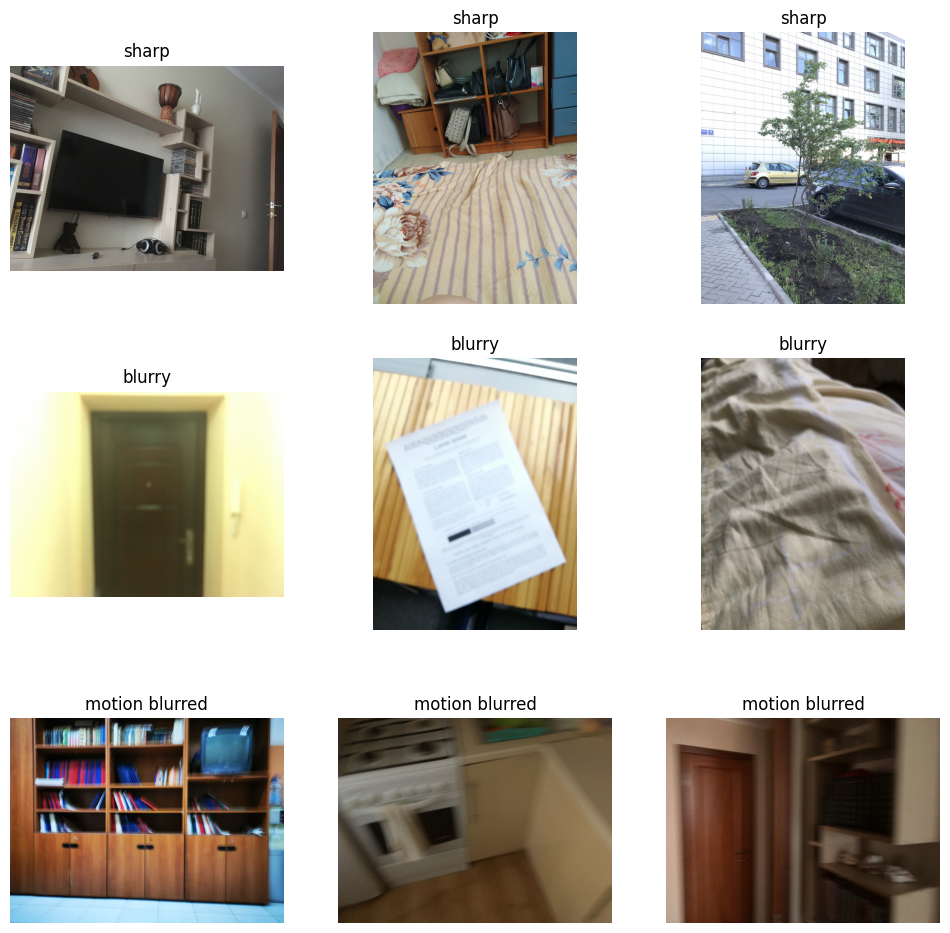

In [38]:
#Loaded 1050 real blurry , motion blurred and sharp images
import matplotlib.pyplot as plt
import cv2
sharp_path = path + "/sharp"
blur_path = path + "/defocused_blurred"
motion_path = path +"/motion_blurred"
sharp_files = os.listdir(sharp_path)
blur_files = os.listdir(blur_path)
motion_files = os.listdir(motion_path)
plt.figure(figsize=(12,12))
for i in range(3):
  img = cv2.imread(sharp_path + "/" + sharp_files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+1)
  plt.imshow(img)
  plt.title("sharp")
  plt.axis("off")

for i in range(3):
  img = cv2.imread(blur_path + "/" + blur_files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+4)
  plt.imshow(img)
  plt.title("blurry")
  plt.axis("off")

for i in range(3):
  img = cv2.imread(motion_path + "/" + motion_files[i])
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(3,3,i+7)
  plt.imshow(img)
  plt.title("motion blurred")
  plt.axis("off")
plt.show()



In [39]:
#Preprocessed and normalised them
images = []
labels = []
for file in sharp_files:
  img= cv2.imread(sharp_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(0)

for file in blur_files:
  img= cv2.imread(blur_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(1)

for file in motion_files:
  img= cv2.imread(motion_path + "/" + file)
  img = cv2.resize(img, (96, 96))
  images.append(img)
  labels.append(1)
#Normalising
import numpy as np
x = np.array(images)/255
y = np.array(labels)
print(x.shape)
print(y.shape)

(1050, 96, 96, 3)
(1050,)


In [47]:
#Used transfer learning - MobileNetV2
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow import keras
from tensorflow.keras import layers
base_model=MobileNetV2(input_shape=(96,96,3), include_top= False, weights="imagenet")
base_model.trainable = False
x_train, x_test , y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])
#Trained binary classifier
model.compile(optimizer="adam", loss="binary_crossentropy" , metrics=["accuracy"])
model.fit(x_train,y_train, epochs=10)
model.evaluate(x_test,y_test)

(840, 96, 96, 3)
(210, 96, 96, 3)
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 185ms/step - accuracy: 0.5881 - loss: 0.8776
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 177ms/step - accuracy: 0.7262 - loss: 0.5422
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.8071 - loss: 0.3940
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.8667 - loss: 0.3240
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 161ms/step - accuracy: 0.8821 - loss: 0.2907
Epoch 6/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - accuracy: 0.9167 - loss: 0.2461
Epoch 7/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step - accuracy: 0.9048 - loss: 0.2209
Epoch 8/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 162ms/step - accuracy: 0.9190 - loss: 0.2008
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - accuracy: 0.9274 - loss: 0.1846
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 163ms/step - accuracy: 0.9417 - loss: 0.1607
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.9095 - loss: 0.2425


[0.24253025650978088, 0.9095237851142883]

In [50]:
#Tested on real photos from your phone
#tested-1(HD)
img = cv2.imread("/content/imghd.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (96,96))
img = np.array(img) / 255
img = img.reshape(1, 96, 96, 3)
prediction = model.predict(img)
print("img1:", "Blurry" if prediction > 0.5 else "Sharp")

#tested-2(blur)
img = cv2.imread("/content/blurimg.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (96,96))
img = np.array(img) / 255
img = img.reshape(1, 96, 96, 3)
prediction = model.predict(img)
print("img2:", "Blurry" if prediction > 0.5 else "Sharp")

#tested-3(motion blur)
img=cv2.imread("/content/motimg.jpg")
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img=cv2.resize(img, (96,96))
img=np.array(img)/255
img=img.reshape(1,96,96,3)
prediction=model.predict(img)
print("img3:","Blurry" if prediction > 0.5 else "Sharp")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
img1: Sharp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
img2: Blurry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
img3: Blurry
